<a href="https://colab.research.google.com/github/UW-CTRL/lmc-exercises/blob/main/12_tracking_lqr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tracking LQR

We will walk through a tracking LQR problem, using all the coding tools and theory we have been building so far.
We will consider the unicycle dynamics model which we studied in exercise 1.

Basically, the tracking LQR problem boils down to a *time-varying* LQR problem. We just need to do additional work and book-keeping to keep track of the time-varying components.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import abc
from typing import Callable, Tuple


In [2]:
# copying code from exercise 1 to set up nonlinear dynamics and other helper functions
class Dynamics(metaclass=abc.ABCMeta):
    """Abstract base class for dynamical systems."""

    dynamics_func: Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray]
    state_dim: int
    control_dim: int

    def __init__(
        self,
        dynamics_func: Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray],
        state_dim: int,
        control_dim: int,
    ):
        """Initializes the Dynamics object.

        Args:
            dynamics_func: A callable representing the dynamics function.
            state_dim: The dimension of the state space.
            control_dim: The dimension of the control space.
        """
        self.dynamics_func = dynamics_func
        self.state_dim = state_dim
        self.control_dim = control_dim

    def __call__(
        self, state: jnp.ndarray, control: jnp.ndarray, time: float = 0.0
    ) -> jnp.ndarray:
        """Evaluates the dynamics function at a given state, control, and time.

        Args:
            state: The current state.
            control: The current control input.
            time: The current time (optional, defaults to 0).

        Returns:
            The next state.
        """
        return self.dynamics_func(state, control, time)


def runge_kutta_integrate(
    dynamics: Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray], dt: float
) -> Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray]:
    """
    Implement Runge-Kutta integration for discrete-time dynamics.

    Args:
        dynamics: A callable representing the continuous-time dynamics function.
        dt: The time step for integration.

    Returns:
        A callable representing the discrete-time dynamics using Runge-Kutta integration.
    """

    # zero-order hold
    def integrator(x: jnp.ndarray, u: jnp.ndarray, t: float) -> jnp.ndarray:
        # TODO: Implement Runge-Kutta integration here
        # raise NotImplementedError # remove this
        dt2 = dt / 2.0
        k1 = dynamics(x, u, t)
        k2 = dynamics(x + dt2 * k1, u, t + dt2)
        k3 = dynamics(x + dt2 * k2, u, t + dt2)
        k4 = dynamics(x + dt * k3, u, t + dt)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    return integrator


def simulate_dynamics(
    dynamics: Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray],
    initial_state: jnp.ndarray,
    control_sequence: jnp.ndarray,
    dt: float,
) -> jnp.ndarray:
    """
    Simulate the discrete-time dynamics over a given time horizon.

    Args:
        dynamics: A callable representing the discrete-time dynamics function.
        initial_state: The initial state of the system.
        control_sequence: A sequence of control inputs for each time step.
        time_horizon: The total time duration for the simulation.
        dt: The time step size.

    Returns:
        An array containing the state trajectory over the time horizon.
    """
    # TODO: Implement dynamics simulation here
    # raise NotImplementedError # remove this
    xs = [initial_state]
    time = 0
    for u in control_sequence:
        xs.append(dynamics(xs[-1], u, time))
        time += dt
    return jnp.stack(xs)



def unicycle_dynamics_func(state, control, time=0):
    """
    Define the unicycle dynamics equations here.

    Args:
      state: The current state of the unicycle (x, y, theta, v).
      control: The control input (omega, a).
      time: The current time (optional).

    Returns:
      The time derivative of the state (dot_x, dot_y, dot_theta, dot_v).
    """
    # TODO: Implement the unicycle dynamics
    x, y, theta, v = state
    omega, a = control
    x_dot = v * jnp.cos(theta)
    y_dot = v * jnp.sin(theta)
    theta_dot = omega
    v_dot = a
    return jnp.array([x_dot, y_dot, theta_dot, v_dot])




In [3]:
# Run this cell to set up the dynamics objects
dt = 0.1
state_dim = 4
control_dim = 2
continuous_dynamics = Dynamics(unicycle_dynamics_func, state_dim, control_dim)

discrete_dynamics = Dynamics(
    runge_kutta_integrate(continuous_dynamics, dt), state_dim, control_dim
)

Text(0, 0.5, 'Y position')

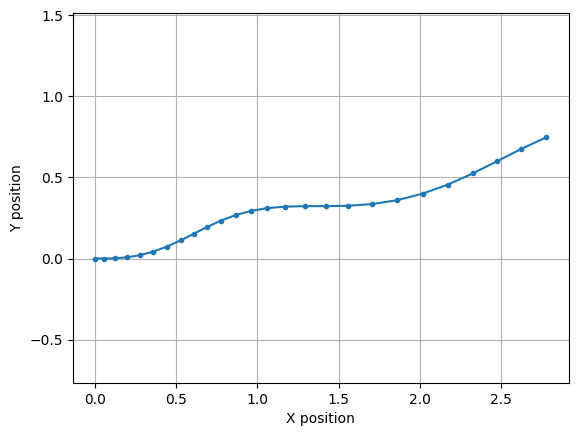

In [4]:
# generate reference trajectory
initial_state = jnp.array([0.0, 0.0, 0.0, 0.5])
n_timesteps = 25
reference_controls = jnp.stack((2 * jnp.sin(jnp.linspace(0, 10, n_timesteps)), 1 + jnp.cos(jnp.linspace(0, 10, n_timesteps)))).T * 0.5
reference_states = simulate_dynamics(discrete_dynamics, initial_state, reference_controls, dt)
plt.plot(reference_states[:, 0], reference_states[:, 1], '.-', label="Position")
plt.grid()
plt.axis("equal")
plt.xlabel("X position")
plt.ylabel("Y position")

### (a) Get $A_t$, $B_t$ for all $t$
We need to linearize the dynamics about each state and control along the reference trajectory. This is something we saw in exercise 1 :)
Compute the linearized $A$ and $B$ matrices for each point along the trajectory.  

In [5]:
# [student response here]

# As has size (n_timesteps, state_dim, state_dim)
# Bs has size (n_timesteps, state_dim, control_dim)
# Note: reference_states has length n_timesteps + 1, but you don't need to linearize about the final state

# As, Bs = ...



### (b) Implement the discrete-time Riccati recursion for the time-varying case.

Use your previous your implementation of `discrete_time_riccati_backward` and adapt it for `discrete_time_riccati_backward_timevarying`.

In [6]:
# [student response here]

def discrete_time_riccati_backward_timevarying(
    As: jnp.ndarray,
    Bs: jnp.ndarray,
    Q: jnp.ndarray,
    R: jnp.ndarray,
    Qf: jnp.ndarray,
    n_timesteps: int,
):
    """
    Solve the discrete-time finite-horizon Riccati equations backwards in time.
    Args:
        As: Time-varying system dynamics matrix.
        Bs: Time-varying control input matrix.
        Q: State cost matrix.
        R: Control cost matrix.
        Qf: Terminal state cost matrix.
        n_timesteps: Number of timesteps in the horizon.
    Returns:
        Ps: List of state cost-to-go matrices at each timestep. Size (n_timesteps + 1, state_dim, state_dim)
        Ks: List of optimal feedback gain matrices at each timestep. Size (n_timesteps, control_dim, state_dim)

    HINT: You may find jnp.linalg.solve useful for solving linear systems. Equivalent to x = A \ b in matlab.
    HINT: Due to numerical issues, it is a good idea to symmetrize P at each step via P = 0.5 * (P + P.T)
    """
    Ks = []
    P = Qf
    Ps = [P]
    ###### YOUR CODE HERE ######

    ############################
    return Ps, Ks

<>:22: SyntaxWarning: invalid escape sequence '\ '
<>:22: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-1085882091.py:22: SyntaxWarning: invalid escape sequence '\ '
  HINT: You may find jnp.linalg.solve useful for solving linear systems. Equivalent to x = A \ b in matlab.


In [7]:
# Cost weights. Choose some values for these matrices.
Q = jnp.eye((state_dim))  # state cost matrix # UPDATE ME
R = jnp.eye((control_dim))  # control cost matrix # UPDATE ME
Qf = jnp.eye((state_dim))  # terminal cost # UPDATE ME

Ps, Ks = discrete_time_riccati_backward_timevarying(As, Bs, Q, R, Qf, n_timesteps)

In [8]:
def rollout_dlqr(
    initial_state: jnp.ndarray,
    reference_states: jnp.ndarray,
    reference_controls: jnp.ndarray,
    dynamics: Callable,
    Ks: jnp.ndarray,
) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Rollout the discrete-time LQR controller over the finite horizon.
    Args:
        initial_state: The initial state vector.
        dynamics_AB: A tuple (A, B) of system dynamics matrices.
        Ks: Sequence of feedback gain matrices for each timestep.
    Returns:
        state_traj: State trajectory over the horizon. Size (n_timesteps + 1, state_dim).
        control_traj: Control trajectory over the horizon. Size (n_timesteps, control_dim).
    """

    state_traj = [initial_state]
    control_traj = []
    ###### YOUR CODE HERE ######

    ############################
    return jnp.array(state_traj), jnp.array(control_traj)


In [9]:
initial_state_offset = initial_state + jnp.array([-0.1, 0.05, 0.05, 0.05])
states, controls = rollout_dlqr(initial_state_offset, reference_states, reference_controls, discrete_dynamics, Ks)

<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipython-input-1049531679.py:13: SyntaxWarning: invalid escape sequence '\o'
  plt.plot(reference_controls[:,0], label='Ref: $\omega$')
/tmp/ipython-input-1049531679.py:15: SyntaxWarning: invalid escape sequence '\o'
  plt.plot(controls[:,0], '--', label='True: $\omega$')


Text(0.5, 1.0, 'Controls')

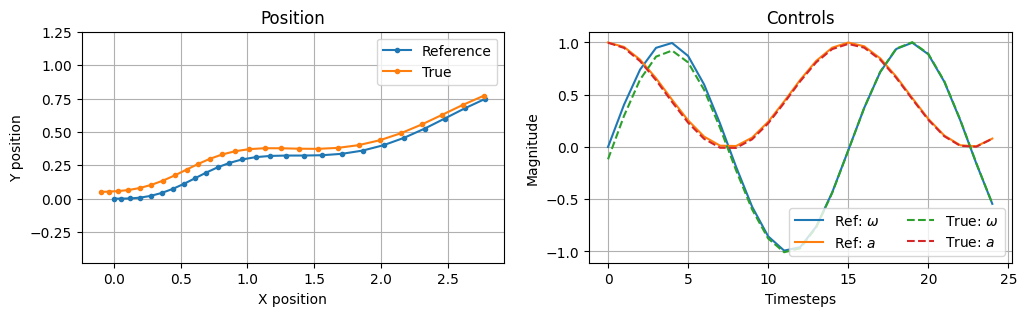

In [10]:
plt.figure(figsize=(12,3))
plt.subplot(1,2,1)
plt.plot(reference_states[:, 0], reference_states[:, 1], '.-', label="Reference")
plt.plot(states[:, 0], states[:, 1], '.-', label="True")
plt.grid()
plt.axis("equal")
plt.xlabel("X position")
plt.ylabel("Y position")
plt.legend()
plt.title("Position")

plt.subplot(1,2,2)
plt.plot(reference_controls[:,0], label='Ref: $\omega$')
plt.plot(reference_controls[:,1], label='Ref: $a$')
plt.plot(controls[:,0], '--', label='True: $\omega$')
plt.plot(controls[:,1], '--', label='True: $a$')
plt.xlabel("Timesteps")
plt.ylabel("Magnitude")
plt.legend(ncols=2)
plt.grid()
plt.title("Controls")